# Train on SageMaker Studio

Goal:

- Train a YOLO model to detect license plates.
- Run in a SageMaker Studio JupyterLab notebook.
- Read raw data from `s3://<bucket>/data/raw/`.
- Export the trained model to `s3://<bucket>/trains/models/`.


## Environment

Install dependencies.


In [1]:
# pip install
%pip install -q -U ultralytics torch torchvision onnx onnxslim

Note: you may need to restart the kernel to use updated packages.


Inspect the runtime environment.


In [2]:
import os
import sys
from importlib.metadata import version
from pathlib import Path

import torch
import torchvision
import ultralytics

from sagemaker.core.helper.session_helper import Session, get_execution_role

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

# define path
RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"
RUNS = ROOT / "runs"
MODELS = ROOT / "models"

# create dir
for d in (RAW, PROCESSED, RUNS, MODELS):
    d.mkdir(parents=True, exist_ok=True)

session = Session()
REGION = session.boto_region_name
ROLE = get_execution_role()

# env_file
env_file = Path.home() / ".sagemaker-yolo.env"
if "BUCKET" not in os.environ and env_file.exists():
    for line in env_file.read_text().splitlines():
        key, _, val = line.partition("=")
        os.environ.setdefault(key.strip(), val.strip())

# get bucket id
BUCKET = os.environ["BUCKET"]

# bucket keys
S3_RAW = f"s3://{BUCKET}/data/raw"
S3_SPLIT = f"s3://{BUCKET}/data/split"
S3_MODELS = f"s3://{BUCKET}/trains/models"

# get device
DEVICE = 0 if torch.cuda.is_available() else "cpu"

# print environment info
print("python         ", sys.version.split()[0])
print("torch          ", torch.__version__)
print("torchvision    ", torchvision.__version__)
print("ultralytics    ", ultralytics.__version__)
print("sagemaker-core ", version("sagemaker-core"))
print("cuda           ", torch.cuda.is_available())
print("device         ", DEVICE)
print("region         ", REGION)
print("bucket         ", BUCKET)
print("root           ", ROOT)

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


python          3.12.13
torch           2.13.0+cu130
torchvision     0.28.0+cu130
ultralytics     8.4.117
sagemaker-core  2.16.0
cuda            False
device          cpu
region          ca-central-1
bucket          sagemaker-yolo-dev-0luf20
root            /home/sagemaker-user/sagemaker-yolo


---

## Data processing

Pull the raw dataset down from S3.


In [3]:
from src.s3_sync import download

# download
print(f"{S3_RAW}/  ->  {RAW}")
print(download(S3_RAW, RAW))

# count images
n_images = len([p for p in RAW.iterdir() if p.suffix.lower() in {".jpeg", ".jpg", ".png"}])
# count lables
n_labels = len([p for p in RAW.iterdir() if p.suffix.lower() == ".txt" and p.name != "classes.txt"])

print(f"images {n_images}  labels {n_labels}")

# if no image, call error.
if n_images == 0:
    raise RuntimeError(f"no images under {S3_RAW}/ — upload the dataset first")

s3://sagemaker-yolo-dev-0luf20/data/raw/  ->  /home/sagemaker-user/sagemaker-yolo/data/raw


{'downloaded': 0, 'skipped': 1113}
images 556  labels 556


Inspect data.


In [4]:
from src.data_loader import summarize

# summarize data
stats = summarize(RAW)
for key, value in stats.items():
    print(f"{key:22} {value}")

pairs                  556
orphan_images          []
orphan_labels          []
boxes_total            574
boxes_per_image_min    1
boxes_per_image_max    3
boxes_per_image_mean   1.03
images_without_boxes   0
class_counts           {'0': 574}
suffixes               {'.jpeg': 543, '.png': 13}
malformed              []


Visualize labels with images.


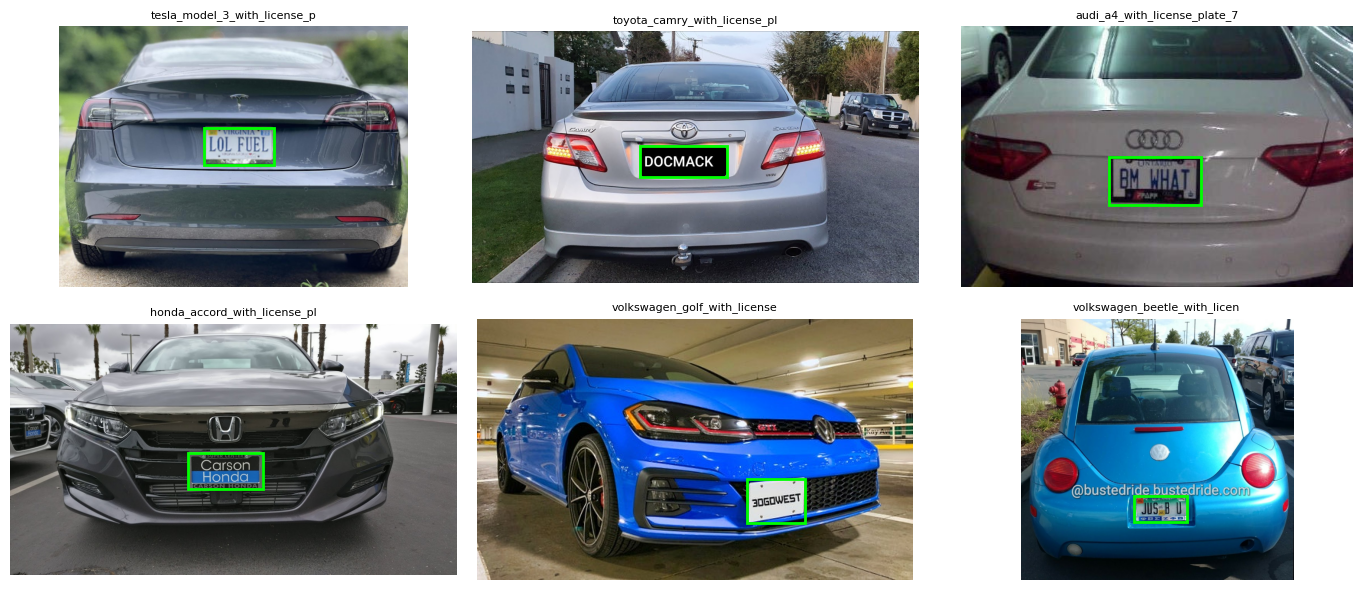

In [5]:
import matplotlib.pyplot as plt
from PIL import Image

from src.data_loader import find_pairs


def show_sample(pairs, n=6, seed=0):
    """Draw label boxes on a few images to confirm the annotations line up."""
    import random

    sample = random.Random(seed).sample(pairs, n)
    fig, axes = plt.subplots(2, n // 2, figsize=(14, 6))
    for ax, (img_path, lbl_path) in zip(axes.ravel(), sample):
        img = Image.open(img_path)
        ax.imshow(img)
        w, h = img.size
        for line in lbl_path.read_text().splitlines():
            if not line.strip():
                continue
            _, cx, cy, bw, bh = (float(v) for v in line.split())
            # YOLO stores normalised centre + size; matplotlib wants corners.
            ax.add_patch(
                plt.Rectangle(
                    ((cx - bw / 2) * w, (cy - bh / 2) * h),
                    bw * w,
                    bh * h,
                    fill=False,
                    edgecolor="lime",
                    linewidth=2,
                )
            )
        ax.set_title(img_path.stem[:28], fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


# show sample
pairs, _, _ = find_pairs(RAW)
show_sample(pairs)

### Split

- Split train/val.
- `LIMIT` caps the number of pairs for a fast smoke run.


In [6]:
from src.data_loader import build_split, verify_split

# e.g. 100 for a fast smoke run
# LIMIT = 100
LIMIT = None  # all images

# split data
print(build_split(RAW, PROCESSED, val_fraction=0.2, limit=LIMIT, seed=0))

# raises on unpaired files or train/val leakage
print(verify_split(PROCESSED))

{'train': 445, 'val': 111, 'orphan_images': 0, 'orphan_labels': 0}
{'train': 445, 'val': 111}


Push the split to S3. Remove stale objects.


In [7]:
from src.s3_sync import list_objects, upload

print(f"{PROCESSED}  ->  {S3_SPLIT}/")

# delete=True drops objects from a previous split
print(upload(PROCESSED, S3_SPLIT, delete=True))

# list spilt
objects = list_objects(S3_SPLIT)
total_bytes = sum(o["size"] for o in objects.values())

print(f"{len(objects)} objects, {total_bytes / 1e6:.1f} MB")

/home/sagemaker-user/sagemaker-yolo/data/processed  ->  s3://sagemaker-yolo-dev-0luf20/data/split/


{'uploaded': 1072, 'skipped': 40, 'removed': 160}


1112 objects, 204.7 MB


### Dataset configuration file

Write `configs/data.yaml`, which points YOLO at the split and names the classes.


In [8]:
from src.data_loader import write_data_yaml

# get name from classes.txt
names = (RAW / "classes.txt").read_text().split()

# Create data config yaml file
data_yaml = write_data_yaml(ROOT / "configs" / "data.yaml", PROCESSED, names)

print(data_yaml.read_text())

path: /home/sagemaker-user/sagemaker-yolo/data/processed
train: train/images
val: val/images
nc: 1
names: ['car_plate']



## Define model

Load the pretrained checkpoint and confirm it lines up with the dataset.

- `yolo11n` is the smallest YOLO11 variant, which matters on a CPU-only space.


### Training hyperparameters

Generated hyperparameters.


In [9]:
from src.data_loader import build_train_cfg

# create training hyperparameters
train_cfg = build_train_cfg(
    device=DEVICE,
    workers=os.cpu_count() or 2,
)

# anchor `project` to the repo
train_cfg["project"] = str(ROOT / train_cfg["project"])

train_cfg

{'model': 'yolo11n.pt',
 'epochs': 10,
 'imgsz': 640,
 'batch': 8,
 'device': 'cpu',
 'workers': 4,
 'seed': 0,
 'project': '/home/sagemaker-user/sagemaker-yolo/runs',
 'name': 'sagemaker-train',
 'exist_ok': True}

In [10]:
from ultralytics import YOLO
from ultralytics.data.utils import check_det_dataset

# Validate dataset; stop id invalid
checked = check_det_dataset(str(data_yaml))
print("dataset ", {k: checked[k] for k in ("nc", "names", "train", "val")})

model = YOLO(train_cfg["model"])

n_params = sum(p.numel() for p in model.model.parameters())
print(f"model    {train_cfg['model']}  {n_params / 1e6:.2f}M params")

# the pretrained head is COCO's 80 classes; ultralytics reshapes it at train time
print(f"classes  pretrained {len(model.names)} -> dataset {checked['nc']} {list(checked['names'].values())}")

dataset  {'nc': 1, 'names': {0: 'car_plate'}, 'train': '/home/sagemaker-user/sagemaker-yolo/data/processed/train/images', 'val': '/home/sagemaker-user/sagemaker-yolo/data/processed/val/images'}
model    yolo11n.pt  2.62M params
classes  pretrained 80 -> dataset 1 ['car_plate']


## Train model

Fine-tune the pretrained checkpoint on the split.


In [11]:
import time

# `model` is not a train() kwarg; the checkpoint is already loaded
cfg = {k: v for k, v in train_cfg.items() if k != "model"}

print(f"training {train_cfg['model']} for {cfg['epochs']} epochs on {cfg['device']}")

start = time.time()
# train model
results = model.train(data=str(data_yaml), **cfg)
elapsed = time.time() - start

print(f"\nelapsed: {elapsed:.0f}s ({elapsed / 60:.1f} min)")

training yolo11n.pt for 10 epochs on cpu


Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.13.0+cu130 CPU (Intel Xeon Platinum 8175M CPU @ 2.50GHz)


engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/sagemaker-user/sagemaker-yolo/configs/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=sagemaker-train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mas

Overriding model.yaml nc=80 with nc=1



                   from  n    params  module                                       arguments                     


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.4s/it 10.0s

                   all        111        116      0.991      0.921       0.98      0.779


Speed: 0.9ms preprocess, 67.6ms inference, 0.0ms loss, 1.8ms postprocess per image


Results saved to /home/sagemaker-user/sagemaker-yolo/runs/sagemaker-train



elapsed: 1657s (27.6 min)


### Training results

Final-epoch metrics on the validation split, and the weights ultralytics kept.

- `best.pt`: the epoch with the highest fitness score; this is what gets exported.
- `last.pt`: the final epoch, for resuming.


In [ ]:
# print save dir
save_dir = Path(results.save_dir)
print("save_dir", save_dir)

print()

# print metrics
for key in ("metrics/precision(B)", "metrics/recall(B)", "metrics/mAP50(B)", "metrics/mAP50-95(B)"):
    print(f"{key:24} {results.results_dict[key]:.4f}")

print()
# print weighted file
for weight in sorted((save_dir / "weights").glob("*.pt")):
    print(f"{weight.name:10} {weight.stat().st_size / 1e6:.1f} MB")

print()
print("artifacts", sorted(p.name for p in save_dir.iterdir() if p.is_file()))

Visualize historical data.


In [ ]:
import pandas as pd

history = pd.read_csv(save_dir / "results.csv")
history.columns = history.columns.str.strip()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for col in ("train/box_loss", "train/cls_loss", "val/box_loss", "val/cls_loss"):
    if col in history:
        axes[0].plot(history["epoch"], history[col], label=col)
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("losses")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# still climbing at the last epoch means more epochs would help
for col in ("metrics/mAP50(B)", "metrics/mAP50-95(B)"):
    if col in history:
        axes[1].plot(history["epoch"], history[col], label=col)
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("mAP")
axes[1].set_title("validation mAP")
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

history.tail(3)

## Eval model

Re-evaluate `best.pt` on the validation split.


In [14]:
# construct the best model
best = YOLO(str(save_dir / "weights" / "best.pt"))

# get metrics
metrics = best.val(
    data=str(data_yaml),
    imgsz=train_cfg["imgsz"],
    batch=train_cfg["batch"],
    device=train_cfg["device"],
    plots=True,
    project=str(save_dir.parent),
    name=f"{save_dir.name}-val",
    exist_ok=True,
)

# print metrics
print(f"mAP50      {metrics.box.map50:.4f}")
print(f"mAP50-95   {metrics.box.map:.4f}")
print(f"precision  {metrics.box.mp:.4f}")
print(f"recall     {metrics.box.mr:.4f}")

Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.13.0+cu130 CPU (Intel Xeon Platinum 8175M CPU @ 2.50GHz)


YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2064.3±859.5 MB/s, size: 157.6 KB)


val: Scanning /home/sagemaker-user/sagemaker-yolo/data/processed/val/labels.cache... 111 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 111/111 29.1Mit/s 0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 7% ╸─────────── 1/14 1.7s/it 0.5s<22.7s

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 1.4it/s 9.7s

                   all        111        116      0.982      0.929       0.98      0.778


Speed: 0.7ms preprocess, 65.8ms inference, 0.0ms loss, 1.8ms postprocess per image


Results saved to /home/sagemaker-user/sagemaker-yolo/runs/sagemaker-train-val


mAP50      0.9802
mAP50-95   0.7780
precision  0.9818
recall     0.9287


### Predictions vs fact

- Green = label
- Red = prediction


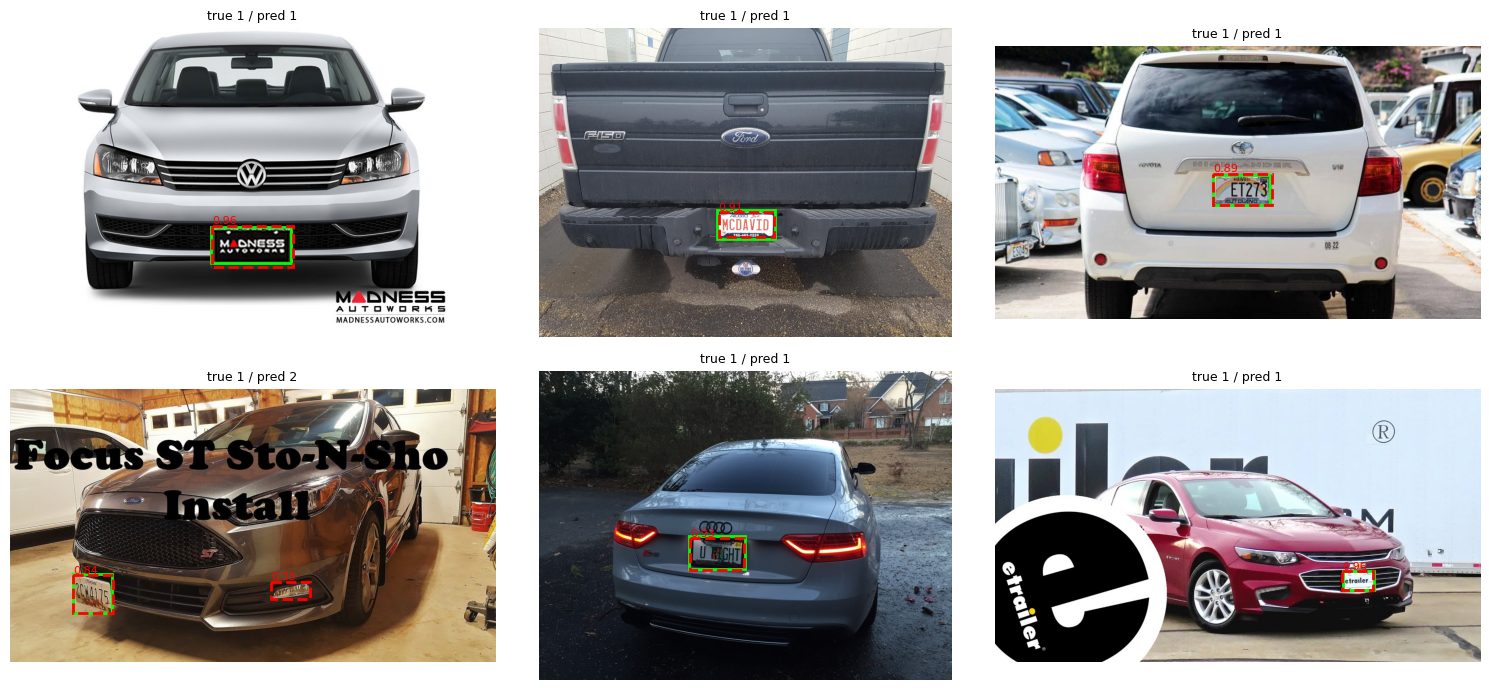

In [15]:
import random


def show_predictions(model, split_dir, n=6, seed=0, conf=0.25):
    """Overlay ground-truth (green) and predicted (red) boxes on val images."""
    images = sorted((split_dir / "images").iterdir())
    sample = random.Random(seed).sample(images, n)

    fig, axes = plt.subplots(2, n // 2, figsize=(15, 7))
    for ax, img_path in zip(axes.ravel(), sample):
        img = Image.open(img_path)
        w, h = img.size
        ax.imshow(img)

        label_path = split_dir / "labels" / f"{img_path.stem}.txt"
        n_true = 0
        for line in label_path.read_text().splitlines():
            if not line.strip():
                continue
            n_true += 1
            _, cx, cy, bw, bh = (float(v) for v in line.split())
            ax.add_patch(
                plt.Rectangle(
                    ((cx - bw / 2) * w, (cy - bh / 2) * h), bw * w, bh * h,
                    fill=False, edgecolor="lime", linewidth=2,
                )
            )

        # imgsz must match training, or boxes land in the wrong place
        result = model.predict(
            img_path,
            imgsz=train_cfg["imgsz"],
            conf=conf,
            device=train_cfg["device"],
            verbose=False,
        )[0]
        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            ax.add_patch(
                plt.Rectangle(
                    (x1, y1), x2 - x1, y2 - y1,
                    fill=False, edgecolor="red", linewidth=2, linestyle="--",
                )
            )
            ax.text(x1, y1 - 4, f"{box.conf.item():.2f}", color="red", fontsize=8)

        ax.set_title(f"true {n_true} / pred {len(result.boxes)}", fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_predictions(best, PROCESSED / "val")

### Missing predictions

List missing predictions


In [16]:
from collections import defaultdict

val_dir = PROCESSED / "val"
images = sorted((val_dir / "images").iterdir())

# Batched rather than one predict() per image — much faster on CPU.
# Chunked to the training batch size to keep memory flat.
batch = train_cfg["batch"]
preds = []
for i in range(0, len(images), batch):
    preds.extend(
        best.predict(
            [str(p) for p in images[i : i + batch]],
            imgsz=train_cfg["imgsz"],
            conf=0.25,
            device=train_cfg["device"],
            verbose=False,
        )
    )

by_true_count = defaultdict(lambda: {"images": 0, "true": 0, "pred": 0, "under": 0})

for img_path, pred in zip(images, preds):
    label_path = val_dir / "labels" / f"{img_path.stem}.txt"
    n_true = len([ln for ln in label_path.read_text().splitlines() if ln.strip()])
    n_pred = len(pred.boxes)

    row = by_true_count[n_true]
    row["images"] += 1
    row["true"] += n_true
    row["pred"] += n_pred
    row["under"] += max(0, n_true - n_pred)

print(f"{'plates/img':>11} {'images':>7} {'labelled':>9} {'detected':>9} {'missed':>7}")
for n_true in sorted(by_true_count):
    r = by_true_count[n_true]
    print(f"{n_true:>11} {r['images']:>7} {r['true']:>9} {r['pred']:>9} {r['under']:>7}")

total_true = sum(r["true"] for r in by_true_count.values())
total_missed = sum(r["under"] for r in by_true_count.values())
print(f"\nmissed {total_missed}/{total_true} plates ({total_missed / total_true:.1%})")

 plates/img  images  labelled  detected  missed
          1     106       106       107       1
          2       5        10         6       4

missed 5/116 plates (4.3%)


### Evaluation plots

Visualize metrics


confusion_matrix_normalized.png


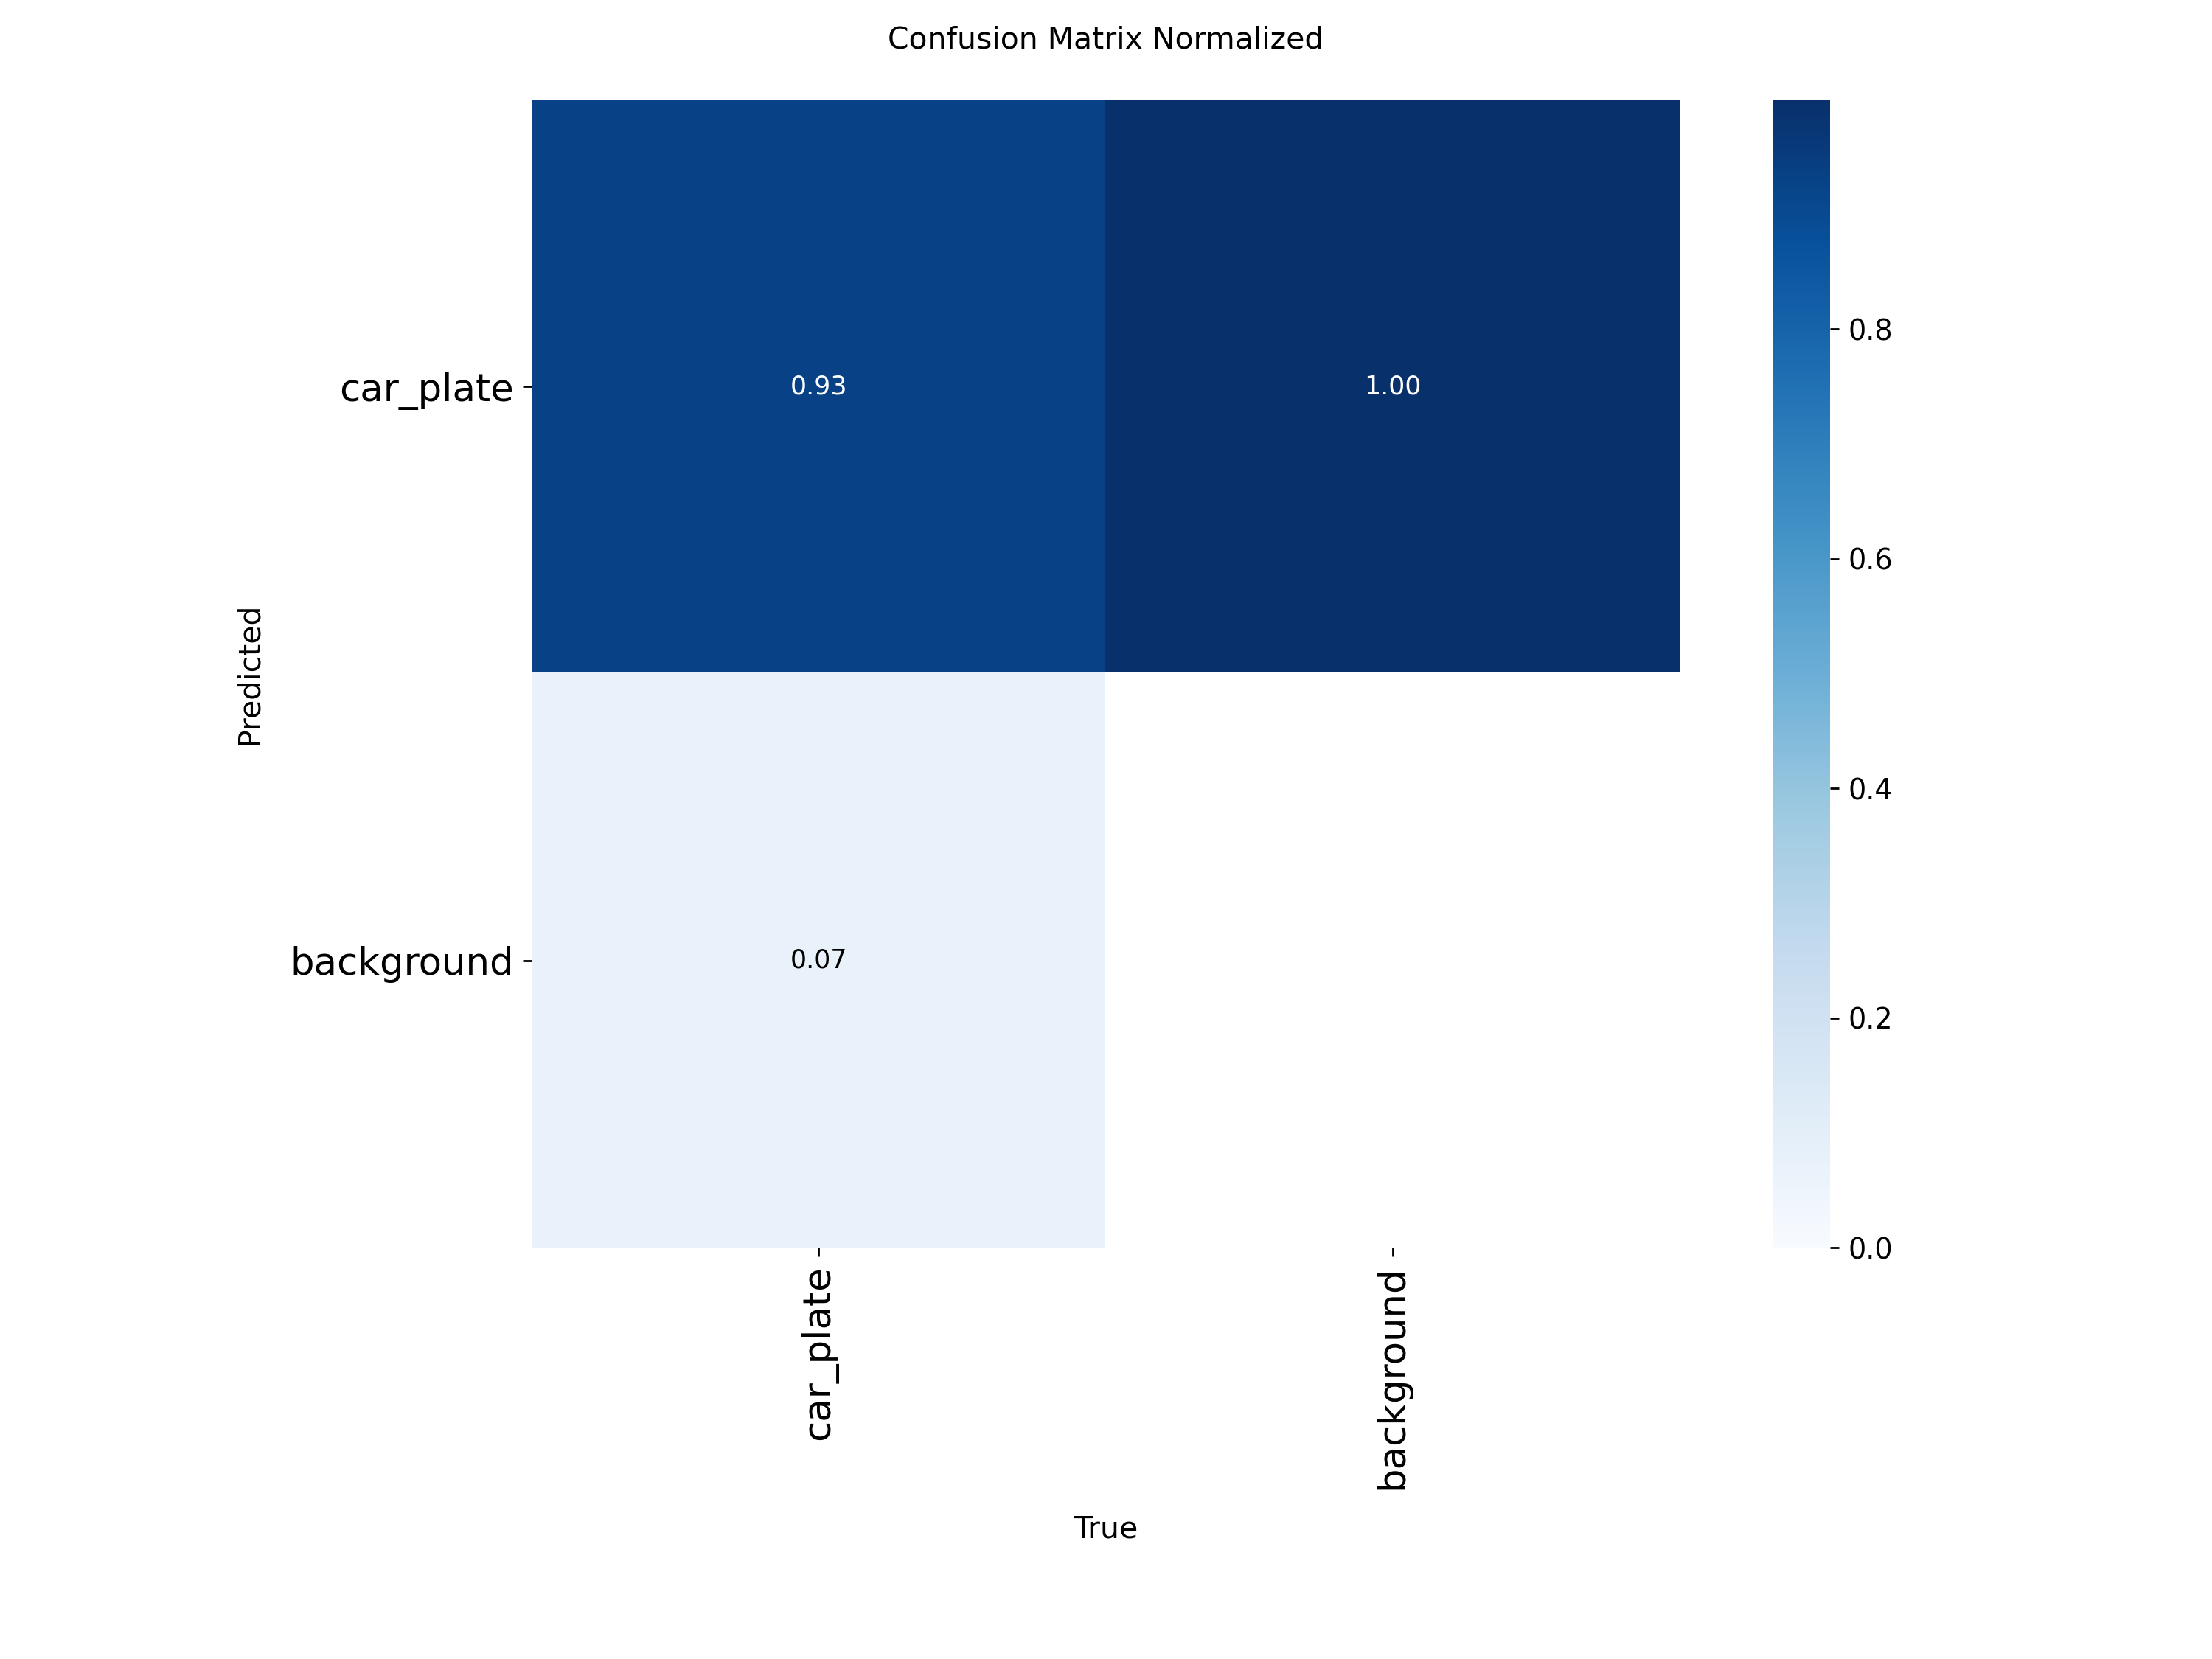

In [17]:
from IPython.display import Image as IPyImage, display

val_dir_out = Path(metrics.save_dir)

for plot in ("PR_curve.png", "confusion_matrix_normalized.png"):
    path = val_dir_out / plot
    if path.exists():
        print(path.name)
        display(IPyImage(filename=str(path), width=560))

## Export model

Export `best.pt` to ONNX and upload it to S3.


In [ ]:
import shutil

# export model
exported = Path(best.export(format="onnx", imgsz=train_cfg["imgsz"], opset=12, simplify=True))

n_images = sum(len(list((PROCESSED / s / "images").iterdir())) for s in ("train", "val"))

# export path
onnx_path = MODELS / (
    f"{train_cfg['name']}-{n_images}img-{train_cfg['epochs']}ep-{train_cfg['imgsz']}px.onnx"
)
shutil.move(str(exported), onnx_path)

print(onnx_path.name)
print(f"{onnx_path.stat().st_size / 1e6:.1f} MB")

Write a metadata file that contrains the input size and classes.


In [ ]:
import json
from datetime import datetime, timezone

sidecar = onnx_path.with_suffix(".metadata.json")
sidecar.write_text(json.dumps({
    "imgsz": train_cfg["imgsz"],
    "names": [best.names[i] for i in sorted(best.names)],
    "metrics": {
        "mAP50": round(metrics.box.map50, 4),
        "mAP50-95": round(metrics.box.map, 4),
        "precision": round(metrics.box.mp, 4),
        "recall": round(metrics.box.mr, 4),
    },
    "train": {k: train_cfg[k] for k in ("model", "epochs", "batch", "seed")},
    "images": n_images,
    "exported_at": datetime.now(timezone.utc).isoformat(),
}, indent=2))

print(sidecar.read_text())

Upload the model, its metadata, and the trained weights to S3.


In [ ]:
from src.s3_sync import list_objects, upload_files

# one prefix per model, so weights and metadata stay together
dest = f"{S3_MODELS}/{onnx_path.stem}"

for uri in upload_files([onnx_path, sidecar, save_dir / "weights" / "best.pt"], dest):
    print(uri)

print()
for key, meta in sorted(list_objects(dest).items()):
    print(f"  {meta['size'] / 1e6:>6.1f} MB  {key.rsplit('/', 1)[-1]}")